In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# --- CONFIGURATION ---
MODEL_PATH = "models/autoencoder_v1.h5"
SCALER_PATH = "processed_data/scaler.save"

# Load Model
print(f"Loading model from {MODEL_PATH}...")
model = tf.keras.models.load_model(MODEL_PATH,compile=False)
model.compile(optimizer='adam', loss='mse')

# Load Data
print("Loading test data...")
X_test_normal = np.load("processed_data/X_test_normal.npy")
X_test_faulty = np.load("processed_data/X_test_faulty.npy")

print(f"Normal Test Samples: {len(X_test_normal)}")
print(f"Faulty Test Samples: {len(X_test_faulty)}")

Loading model from models/autoencoder_v1.h5...
Loading test data...
Normal Test Samples: 67499
Faulty Test Samples: 674999


In [3]:
# Get reconstructions for healthy data
reconstructions_normal = model.predict(X_test_normal)

# Calculate MSE for each sample
# specific axis=(1,2) ensures we get one MSE number per window
mse_normal = np.mean(
    np.square(X_test_normal - reconstructions_normal), axis=(1, 2))

# Define Threshold (Mean + 3 Sigma)
# This covers 99.7% of normal variation. Anything above this is statistically weird.
threshold = np.mean(mse_normal) + 3 * np.std(mse_normal)

print(f"Normal Mean Error: {np.mean(mse_normal):.5f}")
print(f"Normal Max Error:  {np.max(mse_normal):.5f}")
print(f"--------------------------------------")
print(f"ANOMALY THRESHOLD: {threshold:.5f}")
print(f"--------------------------------------")

2110/2110 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step
Normal Mean Error: 0.00071
Normal Max Error:  0.00230
--------------------------------------
ANOMALY THRESHOLD: 0.00133
--------------------------------------


In [4]:
# Get reconstructions for faulty data
reconstructions_faulty = model.predict(X_test_faulty)

# Calculate MSE for faulty data
mse_faulty = np.mean(
    np.square(X_test_faulty - reconstructions_faulty), axis=(1, 2))

print(f"Faulty Mean Error: {np.mean(mse_faulty):.5f}")
print(f"Faulty Min Error:  {np.min(mse_faulty):.5f}")

21094/21094 ━━━━━━━━━━━━━━━━━━━━ 171s 8ms/step
Faulty Mean Error: 0.01213
Faulty Min Error:  0.00135


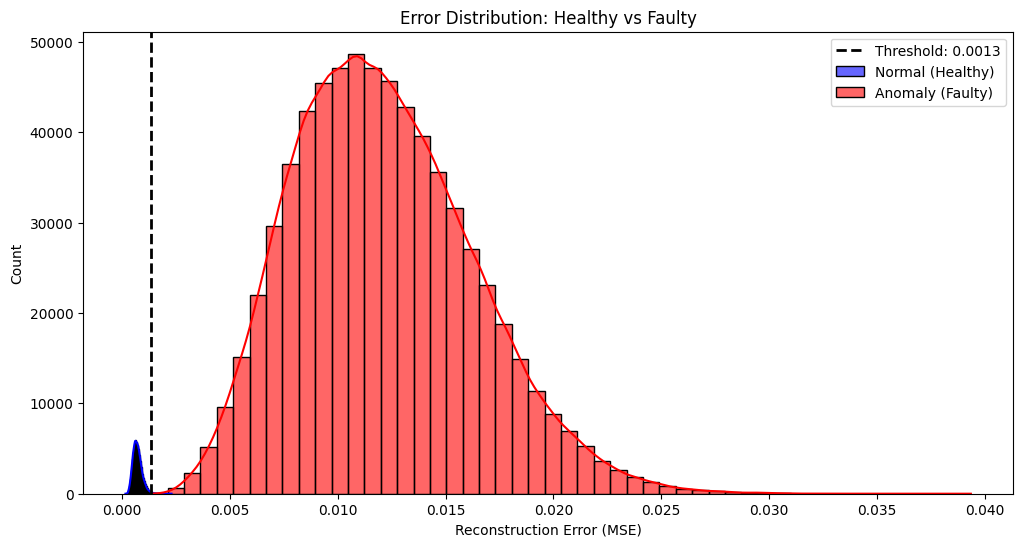

In [5]:
plt.figure(figsize=(12, 6))

sns.histplot(mse_normal, bins=50, color='blue',
             label='Normal (Healthy)', kde=True, alpha=0.6)
sns.histplot(mse_faulty, bins=50, color='red',
             label='Anomaly (Faulty)', kde=True, alpha=0.6)

plt.axvline(threshold, color='black', linestyle='--',
            linewidth=2, label=f'Threshold: {threshold:.4f}')

plt.title("Error Distribution: Healthy vs Faulty")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.legend()
plt.show()

--- Classification Report ---
              precision    recall  f1-score   support

     Healthy       1.00      0.99      1.00     67499
      Faulty       1.00      1.00      1.00    674999

    accuracy                           1.00    742498
   macro avg       1.00      1.00      1.00    742498
weighted avg       1.00      1.00      1.00    742498



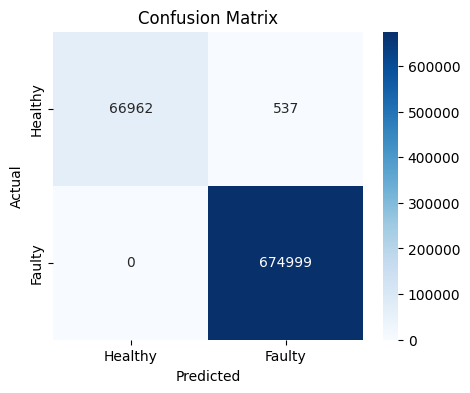

In [6]:
# Classify Normal Data (Should be 0)
# If Error > Threshold -> 1 (Anomaly), else 0 (Normal)
pred_normal = (mse_normal > threshold).astype(int)

# Classify Faulty Data (Should be 1)
pred_faulty = (mse_faulty > threshold).astype(int)

# Combine for final report
y_true = np.concatenate(
    [np.zeros(len(pred_normal)), np.ones(len(pred_faulty))])
y_pred = np.concatenate([pred_normal, pred_faulty])

print("--- Classification Report ---")
print(classification_report(y_true, y_pred,
      target_names=["Healthy", "Faulty"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[
            "Healthy", "Faulty"], yticklabels=["Healthy", "Faulty"])
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

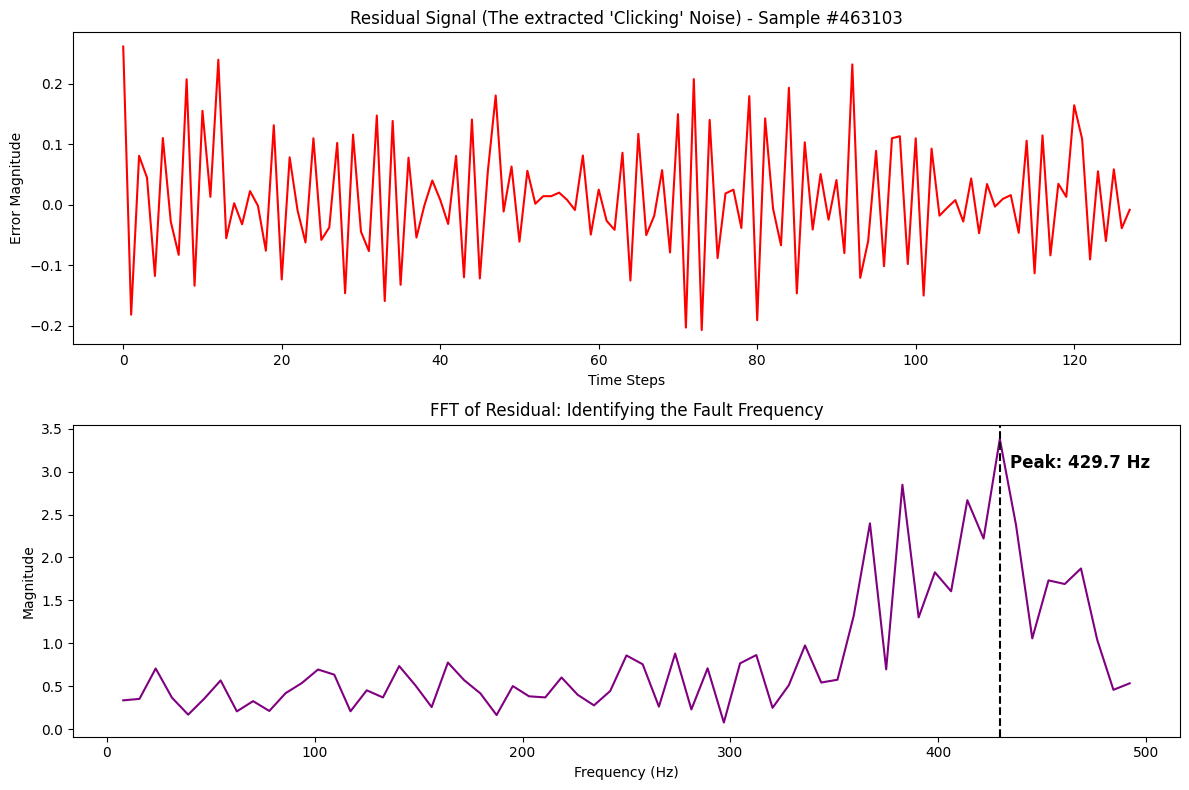

In [17]:
from scipy.fft import fft, fftfreq

def analyze_residual(original, reconstructed, sample_rate=1000):
    # Calculate Residual (The difference)
    # Flatten to 1D array
    residual = (original - reconstructed).flatten()

    # Perform FFT on the Residual
    N = len(residual)
    yf = fft(residual)
    xf = fftfreq(N, 1 / sample_rate)

    # Positive frequencies only
    idx = np.where((xf > 0) & (xf < 500))
    freqs = xf[idx]
    amps = np.abs(yf[idx])

    return freqs, amps, residual


# --- Pick a Random Faulty Sample to Analyze ---
idx = np.random.randint(0, len(X_test_faulty))
sample_in = X_test_faulty[idx:idx+1]
sample_out = reconstructions_faulty[idx:idx+1]

freqs, amps, res_signal = analyze_residual(sample_in, sample_out)

# --- PLOT ---
plt.figure(figsize=(12, 8))

# The Residual Signal (Time Domain)
plt.subplot(2, 1, 1)
plt.plot(res_signal, color='red')
plt.title(f"Residual Signal (The extracted 'Clicking' Noise) - Sample #{idx}")
plt.xlabel("Time Steps")
plt.ylabel("Error Magnitude")

# The FFT of the Residual (Frequency Domain)
plt.subplot(2, 1, 2)
plt.plot(freqs, amps, color='purple')
plt.title("FFT of Residual: Identifying the Fault Frequency")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

# Mark the highest peak
peak_idx = np.argmax(amps)
peak_freq = freqs[peak_idx]
plt.axvline(peak_freq, color='black', linestyle='--')
plt.text(peak_freq + 5, np.max(amps)*0.9,
         f"Peak: {peak_freq:.1f} Hz", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()